<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 7
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Autocorrelation function and comparison between MD and MC
</h2>

This notebook is divided into the following main sections:
- 7.1. Implementation of tail corrections for the potential energy and pressure of our statistical system.

- 7.2:
    - Calculation and analysis of the autocorrelation function for the potential energy, used to determine the correlation time of the simulated process.
    - Estimation and analysis of the statistical uncertainty (Data Blocking) of the mean potential energy as a function of block size, to identify the minimum block size required for statistically independent and reliable error estimates.

- 7.3-7.4: Implementation and sampling of the radial distribution function $g(r)$, a fundamental microscopic quantity that bridges the microscopic structure of the fluid with its macroscopic thermodynamic properties.

We will focus on simulating a Lennard-Jones system, simulated in different ensemble:
- Microcanonical (NVE) ensemble by means of Molecular Dynamics (MD)
- Canonical (NVT) ensemble using Monte Carlo (MCMC) methods based on Boltzmann sampling.

<p style="color: blue; font-size: 25px; font-weight: bold;">
7.1: Tail Correction
</p>
The use of PBCs conditions introduce the following problem: in principle, we must also include all interactions between a molecule and all the images of other molecules. For short-range potential, we can make an approximation: Consider a molecule at rest at the centre of a region which has the same size and shape as the basic simulation box. Then, molecule interacts with all the molecules whose centres lie within this region, that is with the closest periodic images of the other N-1 molecules. This is called the MINIMUM IMAGE CONVENTION. A further approximation is to limit the summation over pairs lying within a sferical cut-off for the potential, and not consider all $N(N-1)/2$ pairs. 

This approximation can be corrected by exploiting the properties of the radial distribution function (see below). The average potential energy can be written as
$$
\langle V\rangle=2\pi N\rho\int_0^\infty dr r^2v(r)g(r)=2\pi N\rho\bigg(\int_0^{r_{cut}}dr r^2v(r)g(r)+\int_{r{cut}}^\infty dr r^2 v(r)g(r)\bigg)=\langle V_cut\rangle+\langle V_{tail}\rangle.
$$
Aanalytical expressions of tail corrections can be derived for both the potential energy and the pressure:
$$
\frac{\langle V_{LJ}\rangle _{tail}}{N}=\frac{8\pi\rho\epsilon}{3r_{cut}^3}\bigg(\frac{1}{3r_{cut}^3}-1\bigg) \\
\frac{\langle P_{LJ}\rangle _{tail}}{N}=\frac{32\pi\rho}{3r_{cut}^3}\bigg(\frac{1}{3r_{cut}^3}-\frac{1}{2}\bigg).
$$
The following plots compare the pressure and the potential energy obtained from two molecular dynamics simulations performed with identical parameters, with and without the tail corrections. In particular,
$$
\rho=0.8,\qquad T=2.4,\qquad \delta=0.001,\qquad N_{Blocks}=20,\qquad N_{step}=2000.
$$

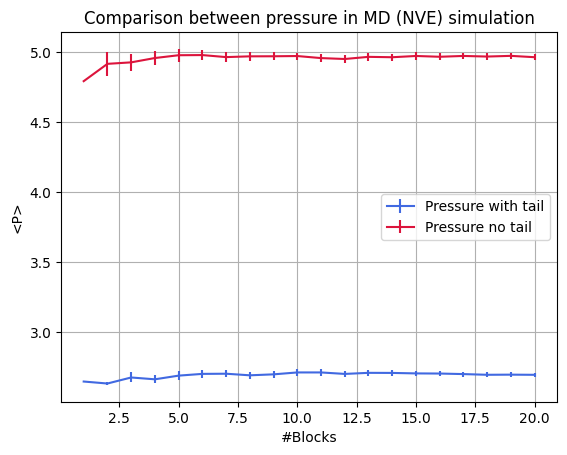

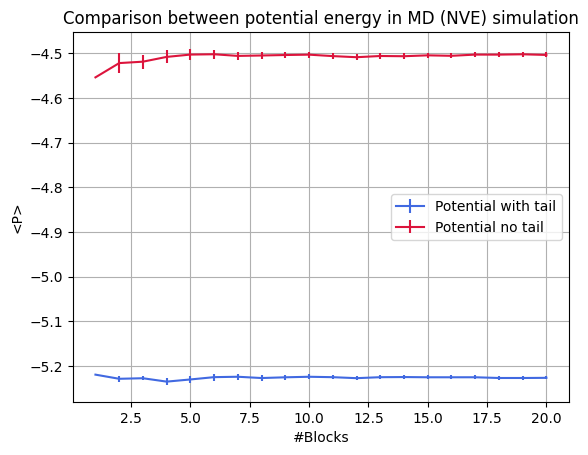

In [52]:
import numpy as np
import matplotlib.pyplot as plt

data_P_tail = np.loadtxt("pressure.dat", comments="#")
data_U_tail = np.loadtxt("potential_energy.dat", comments="#")
data_P = np.loadtxt("../LABORATORIO_4/EX_4.1/NSL_SIMULATOR/OUTPUT/pressure.dat", comments="#")
data_U = np.loadtxt("../LABORATORIO_4/EX_4.1/NSL_SIMULATOR/OUTPUT/potential_energy.dat", comments="#")

blk = data_P[:, 0]
plt.errorbar(blk, data_P_tail[:, 2], yerr=data_P_tail[:, 3], color='royalblue', label='Pressure with tail')
plt.errorbar(blk, data_P[:, 2], yerr=data_P[:, 3], color='crimson', label='Pressure no tail')
plt.xlabel("#Blocks")
plt.ylabel("<P>")
plt.legend()
plt.grid(True)
plt.title("Comparison between pressure in MD (NVE) simulation")
plt.show()

plt.errorbar(blk, data_U_tail[:, 2], yerr=data_U_tail[:, 3], color='royalblue', label='Potential with tail')
plt.errorbar(blk, data_U[:, 2], yerr=data_U[:, 3], color='crimson', label='Potential no tail')
plt.xlabel("#Blocks")
plt.ylabel("<P>")
plt.legend()
plt.grid(True)
plt.title("Comparison between potential energy in MD (NVE) simulation")
plt.show()


<p style="color: blue; font-size: 25px; font-weight: bold;">
7.2: Autocorrelation
</p>

The autocorrelation concept is useful to investigate the presence of memory
or, more precisely, statistical dependence. If $A_c[x](\tau)=0$ for all $\tau>0$, it means that all the values of the process are independent of each other.

If $Ac[x](\tau)=0$ for $\tau>\tau _{c}$ , it implies that the process becomes
independent of its past history only after a lapse of time $\tau _c$, providing a characteristic memory timescale.


If $Ac[x](\tau) ≈ \tau^{-a} a > 0$; $\tau>>0$, one might suspect that memory remains present in the system for all times in a self-similar manner, lacking any memory timescale.

The following script provide an analysis of the correlation in the MC and MD simulations. 

In [53]:
def exp_law(tau, tau_c):
    return np.exp(-tau/tau_c)

U_MC = np.loadtxt("./MC_NVT/CORRELATION_DATA/potential_energy.dat") # delta 0.1, accettanza sul 50 %
U_MD = np.loadtxt("./MD_NVE/CORRELATION_DATA/potential_energy.dat") # t di partenza 2.1, poi il sistema raffredda

def autocorrelation(data, t, tmax):
    A = []
    denominator = np.sum(data[:tmax]**2)/tmax - (np.sum(data[:tmax])/tmax)**2 # il denominatorr è la varianza

    for tp in t:
        numerator = np.sum(data[:tmax-tp]*data[tp:tmax])/(tmax-tp) - (np.sum(data[:tmax-tp])/(tmax-tp)) * (np.sum(data[tp:tmax])/(tmax-tp))
        A.append(numerator/denominator)

    return A

In particular, both simulations are performed using $5\times10^5$ blocks, each consisting of a single Monte Carlo (or Molecular Dynamics) step. The simulation parameters correspond to the liquid phase.

For the NVT simulation, the acceptance rate is tuned to approximately (50%) by properly adjusting the parameter $\delta$, which controls the displacement of the Monte Carlo move:
$$
\rho=0.8,\qquad T=1.1,\qquad \delta=0.1.
$$
Conversely, in the NVE simulation, the temperature is not a conserved quantity. Therefore, the integration time step is kept fixed, while the initial temperature is chosen so that, after equilibration, the system stabilizes at approximately the same temperature as in the NVT simulation:
$$
\rho=0.8,\qquad T=2.02,\qquad \delta=0.001.
$$

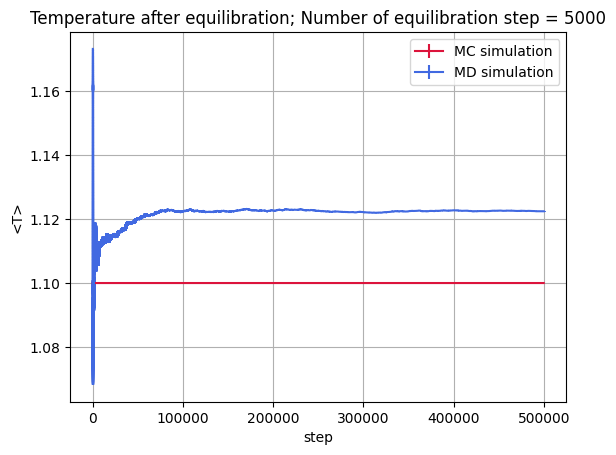

In [54]:
data_T_MC = np.loadtxt("./MC_NVT/CORRELATION_DATA/temperature.dat")
data_T_MD = np.loadtxt("./MD_NVE/CORRELATION_DATA/temperature.dat")
step = data_T_MC[:, 0]
T_MC = data_T_MC[:, 2]
err_T_MC = data_T_MC[:, 3]

T_MD = data_T_MD[:, 2]
err_T_MD = data_T_MD[:, 3]

plt.errorbar(step, T_MC, yerr=err_T_MC, color='crimson', label='MC simulation')
plt.errorbar(step, T_MD, yerr=err_T_MD, color='royalblue', label='MD simulation')
plt.xlabel("step")
plt.ylabel("<T>")
plt.title("Temperature after equilibration; Number of equilibration step = 5000")
plt.legend()
plt.grid(True)
plt.show()

The autocorrelation function will then be fitted with an exponential curve to find the correct proper time $\tau _c$.

In [55]:
from scipy.optimize import curve_fit

t = np.array(U_MC[:1000, 0], dtype=int)
A_MD = autocorrelation(U_MD[:, 1], t, U_MD.shape[0])
A_MC = autocorrelation(U_MC[:, 1], t, U_MC.shape[0])

popt, pcov = curve_fit(exp_law, t, A_MD, p0=10)

tau_c_MD = popt[0]
err_tau_c_MD = np.sqrt(pcov[0, 0])

popt, pcov = curve_fit(exp_law, t, A_MC, p0=10)
tau_c_MC = popt[0]
err_tau_c_MC = np.sqrt(pcov[0, 0])

print(f"Autocorrelation caratteristic time tau_c (MD simulation): {tau_c_MD:.2f} steps")
print(f"Error: {err_tau_c_MD:.2f} steps")

print(f"Autocorrelation caratteristic time tau_c (MC simulation): {tau_c_MC:.2f} steps")
print(f"Error: {err_tau_c_MC:.2f} steps")

Autocorrelation caratteristic time tau_c (MD simulation): 33.25 steps
Error: 0.39 steps
Autocorrelation caratteristic time tau_c (MC simulation): 9.48 steps
Error: 0.16 steps


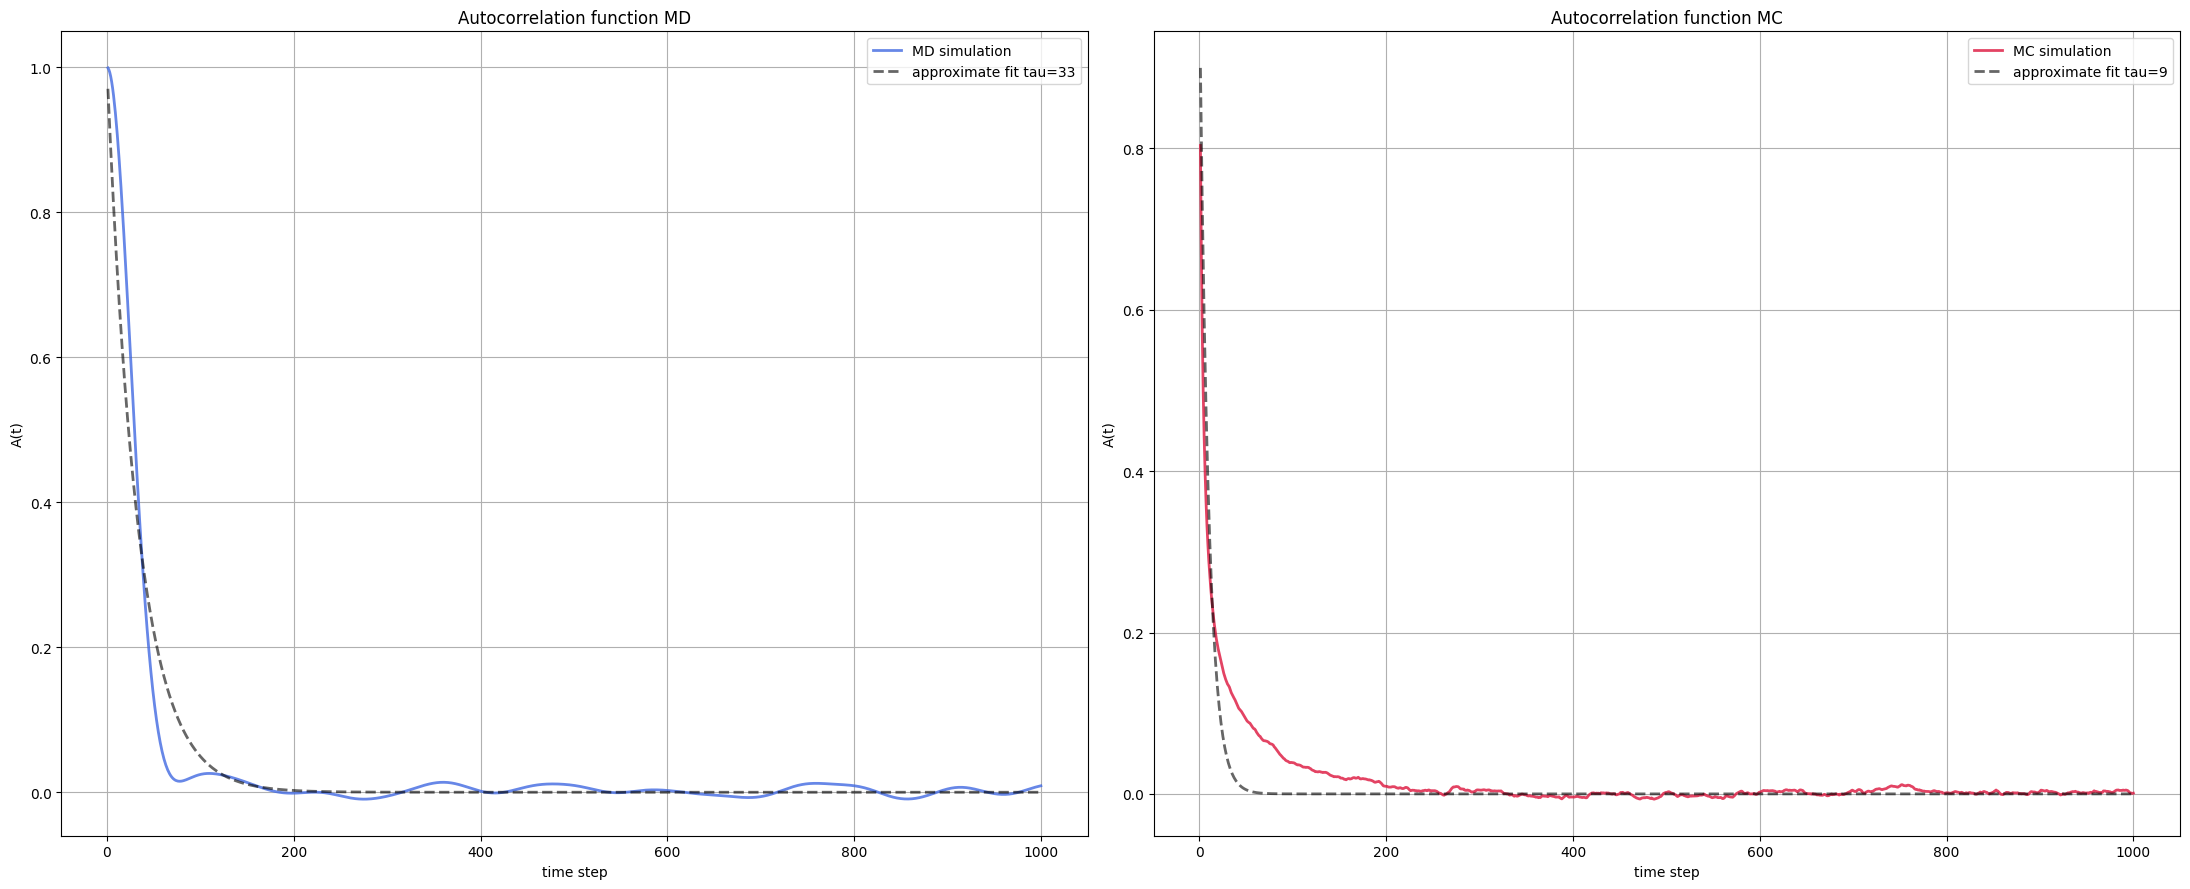

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(22,9))

ax[0].plot(t, A_MD, label="MD simulation", color="royalblue", linewidth=2, alpha=0.8)
ax[0].plot(t,np.exp(-t/tau_c_MD), label=f"approximate fit tau={tau_c_MD.astype(int)}", color="black", linewidth=2, linestyle= "--" ,alpha=0.6)
ax[0].set_title("Autocorrelation function MD")
ax[0].set_xlabel("time step")
ax[0].set_ylabel("A(t)")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t, A_MC, label="MC simulation", color="crimson", linewidth=2, alpha=0.8)
ax[1].plot(t,np.exp(-t/tau_c_MC), label=f"approximate fit tau={tau_c_MC.astype(int)}", color="black", linewidth=2, linestyle= "--" ,alpha=0.6)
ax[1].set_title("Autocorrelation function MC")
ax[1].set_xlabel("time step")
ax[1].set_ylabel("A(t)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

This results highlight the fact that roughly every 33 steps for MD or 9 for MC it's possible to obtain statistically uncorrelated data.

In order to reduce correlations between blocks, their length should be at least greater than the autocorrelation time found.

Now, the focus goes on the dependency of the statistical uncertainties on the block size. It is expected that:
- if $L\leq\tau _c$ the error will be understimated due to correlation
- if $L\geq\tau _c$ the error will be stable and converge around a specific value

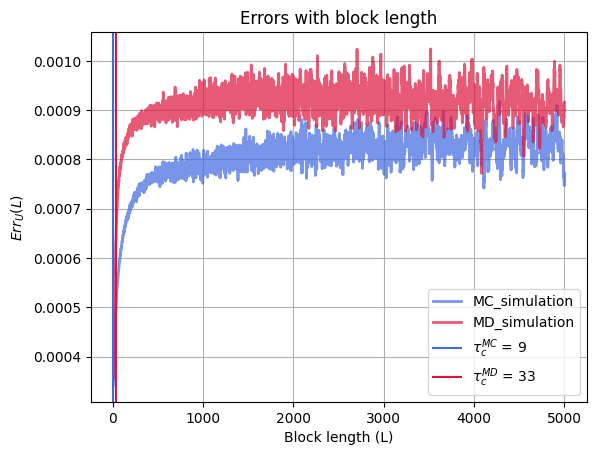

In [57]:
def block_averages(block_size, N_blocks, data):
    data_clip = data[:N_blocks*block_size]

    blocks_values = data_clip.reshape(N_blocks, block_size)
    block_means = np.mean(blocks_values, axis=1)

    average = np.mean(block_means)
    average2 = np.mean(block_means**2)
    err = np.sqrt( (average2 - average**2) / N_blocks)
    return average, err


L = np.arange(10, 5001)
averages = np.zeros((len(L), 2))
errors = np.zeros((len(L), 2))
for i in range(len(L)):
    N_blocks = len(U_MC) // L[i]
    averages[i, 0], errors[i, 0] = block_averages(L[i], N_blocks, U_MC[:, 1])
    averages[i, 1], errors[i, 1] = block_averages(L[i], N_blocks, U_MD[:, 1])

plt.plot(L, errors[:, 0], label='MC_simulation', color='royalblue', linewidth='2', alpha=0.7)
plt.plot(L, errors[:, 1], label='MD_simulation', color='crimson', linewidth='2', alpha=0.7)
plt.axvline(tau_c_MC, color='royalblue', label=rf'$\tau_c^{{MC}}$ = {tau_c_MC.astype(int)}')
plt.axvline(tau_c_MD, color='crimson', label=rf'$\tau_c^{{MD}}$ = {tau_c_MD.astype(int)}')
plt.xlabel("Block length (L)")
plt.ylabel(r"$Err_U(L)$")
plt.title("Errors with block length")
plt.legend()
plt.grid()
plt.show()

As it can be seen, the error begin to converge after a block size largen then $\tau _c$ for both cases, the optimal value is certainly after $L\sim10^3$.

<p style="color: blue; font-size: 25px; font-weight: bold;">
7.3-7.4: Radial distribution function
</p>

The radial (or pair) distribution function gives the probability of finding a pair of atoms a distance r apart, relative to the probability expected for a
completely indipendent particles system at the same density (ideal gas). It is defined starting from the n-particles density distribution which is then divided for the n-particles density distribution of an ideal gas, which is merely the product of the one body density function, because the variables are indipendent.

The algorithm used for the 2-particle radial distribution function for an homogeneus liquid (this property lead that $g^2(\mathbf{r}_1,\mathbf{r}_2)=g^2(|\mathbf{r}_1-\mathbf{r}_2)|=g(r)$) is:
$$
g(r)=\frac{1}{\rho N \Delta V(r)}\big\langle \sum_{i\neq j}\delta(|\mathbf{r}|-|\mathbf{r}_i-\mathbf{r}_j|)
$$
where the factor
$$
\Delta V(r)=\frac{4\pi}{3}\big[(r+dr)^3-r^3\big],
$$
is due to the average process over the angles. In practice every time a couple of particles the corresponding bin must be incresead. Since the previous formula require tho loop over a single particle with $i\neq j$, we can obtain the same result using a double loop over pairs and then increase with +2.
```cpp
for (int i=0; i<_npart-1; i++){
    for (int j=i+1; j<_npart; j++){
        distance(0) = this->pbc( _particle(i).getposition(0,true) - _particle(j).getposition(0,true), 0);
        distance(1) = this->pbc( _particle(i).getposition(1,true) - _particle(j).getposition(1,true), 1);
        distance(2) = this->pbc( _particle(i).getposition(2,true) - _particle(j).getposition(2,true), 2);
        dr = sqrt( dot(distance,distance) );
        int bin=(int)(dr/_bin_size);
        if(bin<_n_bins) _measurement(_index_gofr+bin)+=2;
    }
}
// normalization
for(int i=0; i<_n_bins; i++){
    double r1 = i*_bin_size;
    double r2 = (i+1) * _bin_size;
    double vol = (4 * M_PI / 3.0) * (pow(r2, 3) - pow(r1, 3));
    double norm = _rho * _npart * vol;
    _measurement(_index_gofr+i) /= norm;
}
```

In [58]:
U_MC_data = np.loadtxt("./MC_NVT/SIMULATION/potential_energy.dat") # delta 0.1, accettanza sul 50 %
blocks = U_MC_data[:, 0]
U_MC = U_MC_data[:, 2]
err_U_MC = U_MC_data[:, 3]
U_MD_data = np.loadtxt("./MD_NVE/SIMULATION/potential_energy.dat") # t di partenza 2.1, poi il sistema raffredda
U_MD = U_MD_data[:, 2]
err_U_MD = U_MD_data[:, 3]

P_MC_data = np.loadtxt("./MC_NVT/SIMULATION/pressure.dat")
P_MC = P_MC_data[:, 2]
err_P_MC = P_MC_data[:, 3]
P_MD_data = np.loadtxt("./MD_NVE/SIMULATION/pressure.dat")
P_MD = P_MD_data[:, 2]
err_P_MD = P_MD_data[:, 3]

gofr_MC_data = np.loadtxt("./MC_NVT/SIMULATION/gofr.dat")
d = gofr_MC_data[:, 1]
GO_MC = gofr_MC_data[:, 2]
err_GO_MC = gofr_MC_data[:, 3]
gofr_MD_data = np.loadtxt("./MD_NVE/SIMULATION/gofr.dat")
GO_MD = gofr_MD_data[:, 2]
err_GO_MD = gofr_MD_data[:, 3]

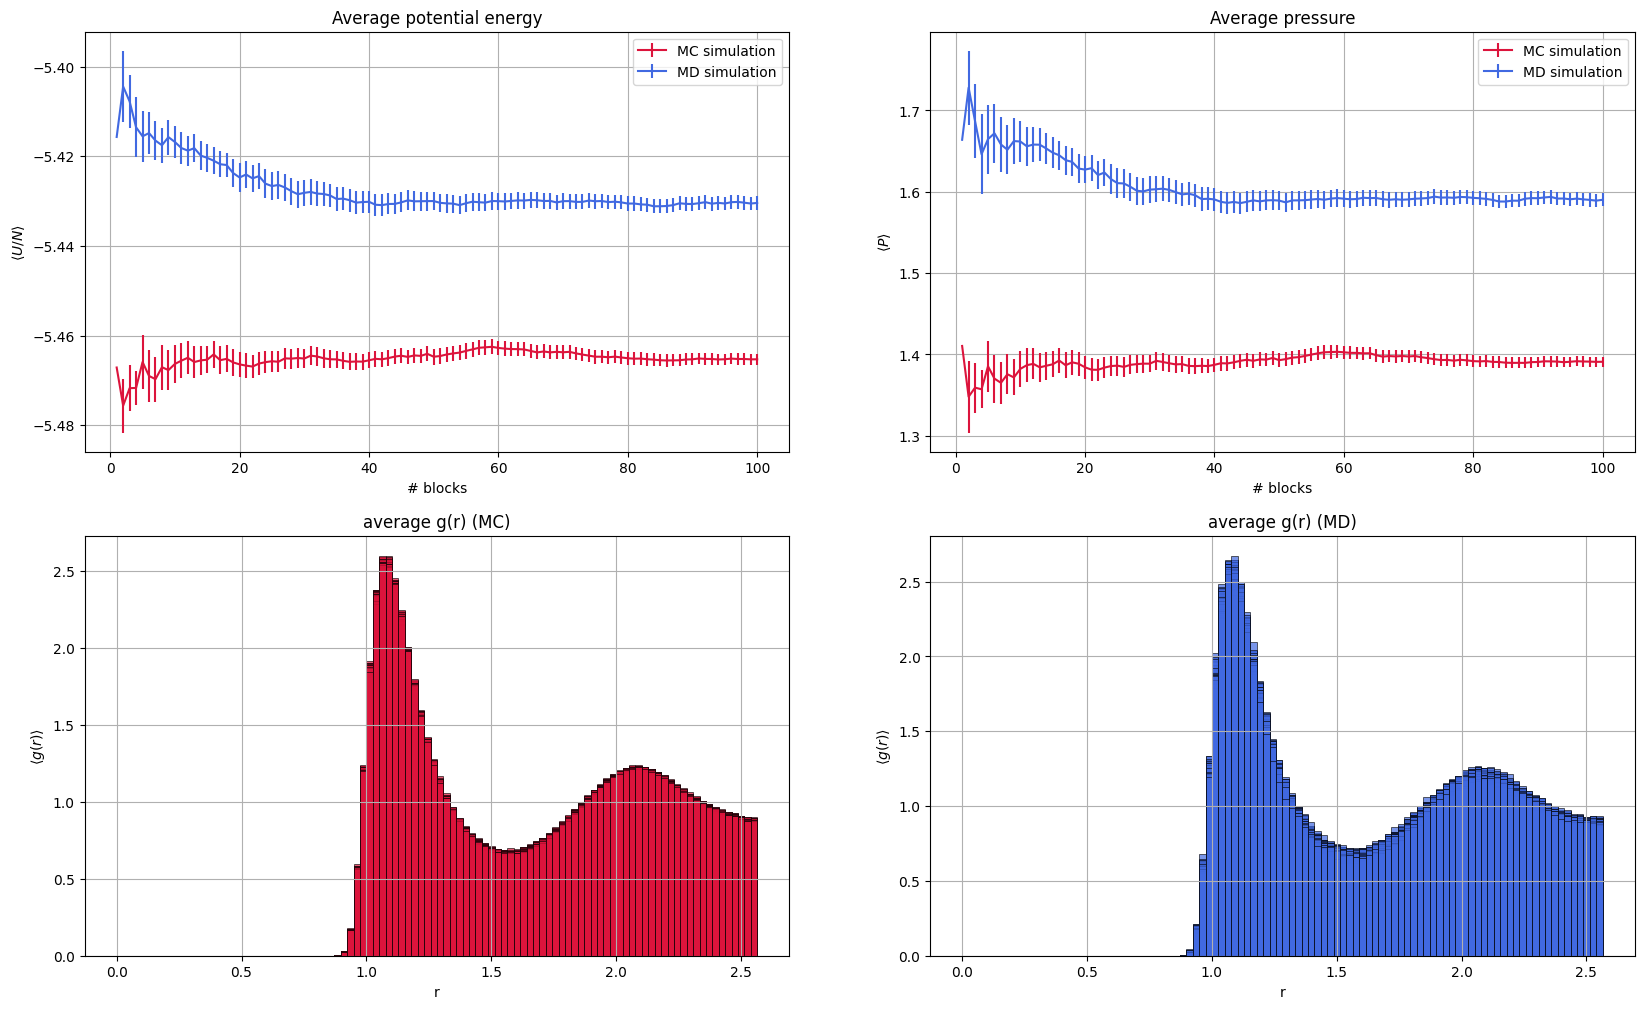

In [59]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
ax=ax.flatten()
ax[0].errorbar(blocks, U_MC, yerr=err_U_MC, color='crimson', label='MC simulation')
ax[0].errorbar(blocks, U_MD, yerr=err_U_MD, color='royalblue', label='MD simulation')
ax[0].set_xlabel("# blocks")
ax[0].set_ylabel(r"$\langle U/N \rangle$")
ax[0].set_title("Average potential energy")
ax[0].grid(True)
ax[0].legend()

ax[1].errorbar(blocks,P_MC, yerr=err_P_MC, color='crimson', label="MC simulation")
ax[1].errorbar(blocks,P_MD, yerr=err_P_MD, color='royalblue', label="MD simulation")
ax[1].set_xlabel("# blocks")
ax[1].set_ylabel(r"$\langle P \rangle$")
ax[1].set_title("Average pressure")
ax[1].grid(True)
ax[1].legend()

ax[2].bar(d, GO_MC, width=(d[1]-d[0]), align='center', alpha=0.7, color='crimson', edgecolor='black', linewidth=0.6)
ax[2].set_xlabel("r")
ax[2].set_ylabel(r"$\langle g(r) \rangle $")
ax[2].set_title("average g(r) (MC)")
ax[2].grid(True)


ax[3].bar(d, GO_MD, width=(d[1]-d[0]), align='center', alpha=0.7, color='royalblue', edgecolor='black', linewidth=0.6)
ax[3].set_xlabel("r")
ax[3].set_ylabel(r"$\langle g(r) \rangle$")
ax[3].set_title("average g(r) (MD)")
ax[3].grid(True)


plt.show()


<p style="color: green; font-size: 25px; font-weight: bold;">
Conclusions
</p>

Both simulations produce an identical radial distribution function.

As can be observed from the graphs, the two simulations yield very similar, although not statistically compatible, estimates for the mean values of potential energy per particle and pressure.
This is due mainly to the difficulty in maintaining tight control over the average temperature during the microcanonical ensemble simulation such that it precisely matches the fixed temperature of the canonical ensemble simulation and the limited duration of the simulations, which may lead to insufficient sampling.

Despite this, this allows us to draw a crucial conclusion: **the dynamic microscopic analysis of a complex system (as simulated by Molecular Dynamics) coincides with the statistical analysis of configurational probability distribution sampling for a complex system (as simulated by Markov Chain Monte Carlo)**.
